<a href="https://colab.research.google.com/github/Yogi-Puvvala/resume_analyzer/blob/main/Resume_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
VOCAB_SIZE  = 10000
MAX_LENGTH  = 300

In [6]:
NUM_CLASSES     = 24
EMBEDDING_DIM   = 128
LSTM_UNITS      = 64

model = Sequential()
model.add(Embedding(input_dim = VOCAB_SIZE,
              output_dim = EMBEDDING_DIM,
              input_length = MAX_LENGTH))
model.add(SpatialDropout1D(0.2))

model.add(Bidirectional(LSTM(LSTM_UNITS,
                       return_sequences = True)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.3))

model.add(Dense(32, activation = 'relu'))
model.add(Dropout(0.2))

model.add(Dense(NUM_CLASSES, activation = 'softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer = tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [8]:
EPOCHS     = 20
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

In [9]:
import pickle

In [11]:
with open("X_train_pad.pkl", "rb") as f:
    X_train_pad = pickle.load(f)

with open("X_test_pad.pkl", "rb") as f:
    X_test_pad = pickle.load(f)

with open("y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open("y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

In [12]:
history = model.fit(
    X_train_pad, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_test_pad, y_test),
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.0689 - loss: 3.1378 - val_accuracy: 0.1469 - val_loss: 2.9442 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.1877 - loss: 2.6690 - val_accuracy: 0.3863 - val_loss: 2.2703 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3754 - loss: 2.0688 - val_accuracy: 0.5433 - val_loss: 1.7296 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5254 - loss: 1.5856 - val_accuracy: 0.6640 - val_loss: 1.4307 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6442 - loss: 1.2481 - val_accuracy: 0.6841 - val_loss: 1.2768 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7141 - loss: 0.9931 - val_accuracy: 0.6680 - val_loss: 1.2935 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7826 - loss: 0.7900 - val_ac

In [15]:
import matplotlib.pyplot as plt
history = history.history

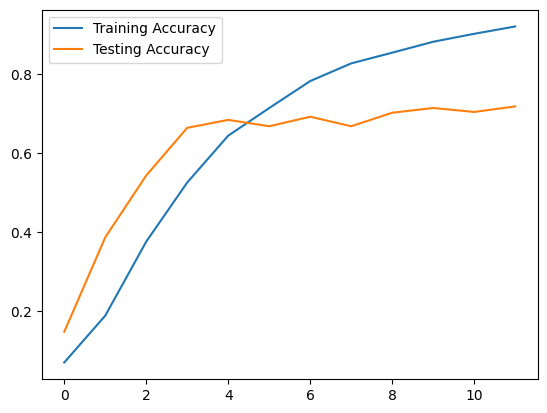

In [17]:
plt.plot(history["accuracy"], label = "Training Accuracy")
plt.plot(history["val_accuracy"], label = "Testing Accuracy")
plt.legend()

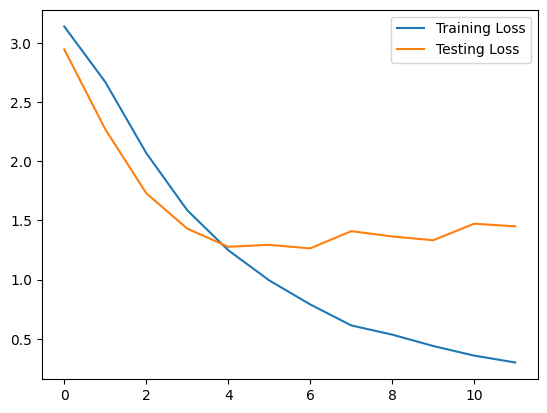

In [18]:
plt.plot(history["loss"], label = "Training Loss")
plt.plot(history["val_loss"], label = "Testing Loss")
plt.legend()

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
model.save('/content/drive/MyDrive/ML_Models/my_model.keras')